In [3]:
#step 1: Import  Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
np.random
data = pd.DataFrame({
    "hours_studies":np.random.randint(1, 10, 50),
    "attendance": np.random.randint(50, 100, 50),
})
data.head()

,hours_studies,attendance
0,8,69
1,5,96
2,4,50
3,6,69
4,7,84


In [8]:
X = data[["hours_studies", "attendance"]]
model = KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"] = model.fit_predict(X)
data.head()

,hours_studies,attendance,cluster
0,8,69,0
1,5,96,1
2,4,50,2
3,6,69,0
4,7,84,1


In [13]:
score = silhouette_score(X, data["cluster"])
print("Silhouett Score:", score)

Silhouett Score: 0.6132064978026015


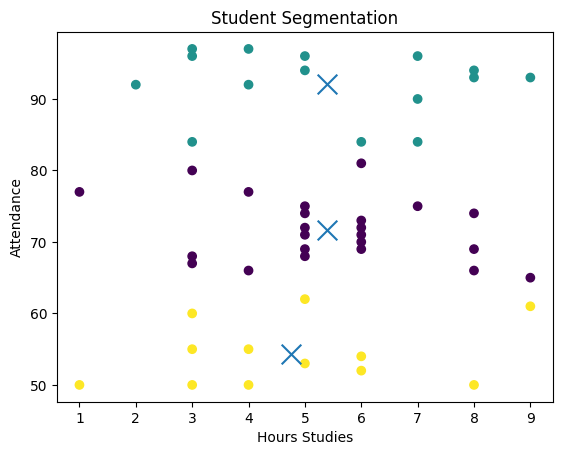

In [15]:
plt.scatter(data["hours_studies"], data["attendance"], c=data["cluster"])
centers = model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            marker="x", s=200)
plt.xlabel("Hours Studies")
plt.ylabel("Attendance")
plt.title("Student Segmentation")
plt.show()

In [23]:
# Example: New student
# hours_studied = 6, attendance = 80
new_student = [[6, 80]]
predicted_cluster = model.predict(new_student)
print("New student belongs to cluster:", predicted_cluster[0])

New student belongs to cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [25]:
data.groupby("cluster").mean()

,hours_studies,attendance
cluster,,
0,5.391304,71.695652
1,5.400000,92.133333
2,4.750000,54.333333
